<br>

## **Data Analysis of Galaxy Data using Fixed Magnitude and Fixed Diameter**


<br>

##### Maybelline M. Zuniga Perez

<br>
<br>

### **Domain-Specific Area and Objectives**


**Domain Area**
<br>

The Domain area will be Observational Cosmology, focusing specifically on the motion of spiral galaxies to model the expansion rate of the universe as a continuation from a previous project. Linear regression is used quite often in astronomy, as it can handle large datasets quickly and produce visualizations.


**Objectives**
<br>
In this project, we will go deeper and find the distance of each spiral galaxy from Earth using two different methods to plot the linear relationship between recessional velocity and distance and to find the slope ( Hubble's constant). Although Hubble's constant has already been calculated, this project will show why there is still much debate and uncertainty. 

The two different methods we will use to analyze spiral galaxies are the Fixed Diameter method and the Fixed Magnitude method. We will then calculate the age of our universe for both constants and show the discrepancies compared to Hubble's constant estimated from the cosmic microwave background, 67km/s/Mpc. 

**Contributions**
<br>
The discrepancy between early universe Hubble's constant and late universe Hubble's constant is called Hubble's Tension. An inaccurate constant affects our ability to find the correct distances of galaxies and other celestial objects, as well as the age and behavior of the universe. For example, having a universe with a rate of expansion faster than when it was a baby leads us to think that there could be dark energy or some other thing that is causing it to expand faster. On the other hand, if the rate is lower in our late universe than early universe, we assume that the universe is slowing down.


**The Fixed Diameter Method**
<br>

The first method will come from an online science lab from the University of Washington, where they use 27 galaxy images from the University of Arizona and the equation below to calculate distance. This is assuming the true diameter of the galaxy is about the same as that of the M31 Andromeda Galaxy, 22 kpc.

$$d = s / a$$

* d is the distance to the galaxy 
* s is the true diameter of the galaxy 
* a is the apparent angular size

  
**The Fixed Magnitude Method** 
<br>

The second method will use the distance modulus and assume that the absolute magnitude, M = -20.5. This is because we do not have the absolute magnitude, but we do have the apparent magnitude. With over 1000 spiral galaxies in our data, hopefully, the small differences don't drastically change the results. 

$$d = 10^{\frac{m-M+5}{5}}$$

* d is the distance to the galaxy
* m is the apparent magnitude
* M is the absolute Magnitude

<br>

**Hubble's Law**
<br>

After we find the distance for each spiral galaxy using both methods, we will use linear regression to find Hubble's constant with the equation and model it.

$$ v = H_{0}D $$

* v is the recession velocity from Earth
* $H_{0}$ is the slope, Hubble's constant
* D is the distance from the Earth
  
<br>



### **Dataset Description**



#### **Fixed Diameter Method**
<br>

**Source**
<br>
> https://depts.washington.edu/astroed/HubbleLaw/measurements.html

**Origin and Directions**
<br>
The data acquired from the lab was manually entered into a Google Sheet file by following the lab instructions. To find Hubble's constant in the lab, we need to find the recessional velocity and distance from Earth. 

This dataset of 27 galaxies comes from the University of Washington's Hubble Law lab. The data were acquired by manually measuring the calcium H and K absorption lines (2 lowest troughs) and the Hα emission line (the highest peak) for each galaxy. All 3 wavelengths were notated to find the redshift. We used the equation: redshift =(measured wavelength - rest wavelength) / rest wavelength. After finding the average redshift, we found the average for all 3 and added it to the data file as the average redshift. With the average redshift, we found the recessional velocity using the speed of light: velocity = redshift x speed of light.

Now, with the distances from Earth, we used a fixed diameter of 22 kpc for each galaxy, and we measured the angular size of each galaxy through images. To solve for distance, we used the equation: distance = diameter / apparent angular size.

**Structure and Data Types**
<br>
The dataset created has 27 rows by 11 columns, including Object Name, Ca K (Å), Ca H (Å), Hα (Å), Ca K Redshift, Ca H Redshift, Hα Redshift, Average Redshift, Velocity (km/s), Galaxy Size (mrad), and Distance (Mpc). The data types are strings and floating numbers. We are keeping floating numbers until the very end for accurate data modeling. 									

**Fitness for LR**
<br>
The data is highly fit for linear regression with the linear relationship between velocity and distance. The slope m will be Hubble's constant. Since the dataset is only 27 galaxies, we can see that there are no duplicates, no missing data, no multiple entries, or extra cleaning to do. 

#### **Fixed Magnitude Method**
<br>

**Source**
<br>
> https://ned.ipac.caltech.edu/
<br>
> 
**Origin**
This data is sourced from the NASA/IPAC Extragalactic Database (NED). Data had to be constrained to enable download. The data file given from the website was a text file, but was converted to a CSV file and then loaded and cleaned. This data will be used for the Fixed Magnitude Method. We use constraints for z = Redshift to avoid relativistic effects. When z < 0.1, then the Hubble constant error is negligible. 
<br>


**Directions**
<br>
> => https://ned.ipac.caltech.edu/byparams<br>
> => Search Objects<br>
> => By Parameters<br>
> => Redshift Constraints: Between 0 < z < 0.050<br>
> => Photometric Constraints: Flux density: Between: 0.1 and 10, Flux Unit: Jy, Spectral Region: Optical, Spectral Band: Full Spectral Region<br>
> => Object Type Constraints: Inclusions: Classified Extragalactic Galaxies: (G)<br>

**Structure and Data Types**
<br>
The data downloaded has 1120 rows and  17 columns. The column headings are Number, Object Name, Right Ascension, Declination, Type, Velocity, Redshift, Redshift Flag, Magnitude and Filter, Separation, References, Notes, Photometry Points, Positions, Redshift Points, Diameter Points, Associations. The data types are integer, string, and floating-point numbers. The data already comes with rounded integers for velocity, so we will leave it as an integer. The other columns, like Distance, will be used for data modeling and will remain as floating numbers. 

**Fitness for LR**
<br>
The data are suitable for linear regression because we have redshift and velocity, and we can compute distances from the apparent magnitude already present in the data. We can use the distance modulus and use a fixed value for absolute magnitude (data is missing M) to solve for distance. Once we find all the distances, we can plot the Linear Relationship between velocity and distance to find the slope, Hubble's constant. 
<br>
<br>

### **Data Preparation**

#### **Fixed Diameter Method**
<br>

**Acquisition/Cleaning/Sanitisation/Normalisation**

The dataset was acquired through an online lab using the radial size of galaxies to find the distance. Since we only have 27 galaxies, with columns for redshift, velocity, and distance, we can easily check the data set for duplicates, missing values, wrong or multiple entries, and wrong data types. The data set we created we made sure it was in first normal form. The data from the lab has been curated so that cleaning is not necessary, but cleaning is necessary for the Fixed Magnitude Method. In that one we take raw data straight from NED. 

In [1]:
%pip install pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
#load libraries
import pandas as pd
import numpy as np

#load data
lab_data=pd.read_csv(r"C:\Users\maybe\OneDrive\Desktop\One elective Data Science\lab_data.csv")

#check first rows to verify it loaded correctly
print(lab_data.head(1))

  Object Name  Ca K (Å)  Ca H (Å)  Hα (Å)  Ca K Redshift  Ca H Redshift  \
0    NGC 1357    3962.2    3997.8  6607.5       0.007245       0.007383   

   Hα Redshift  Average Redshift  Velocity(km/s)  Galaxy Size(mrad)  \
0     0.006811          0.007146     2142.451489               0.85   

   Distance(Mpc)  
0      25.974026  


In [3]:
#data types and null values 
lab_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Object Name        27 non-null     str    
 1   Ca K (Å)           27 non-null     float64
 2   Ca H (Å)           27 non-null     float64
 3   Hα (Å)             27 non-null     float64
 4   Ca K Redshift      27 non-null     float64
 5   Ca H Redshift      27 non-null     float64
 6   Hα Redshift        27 non-null     float64
 7   Average Redshift   27 non-null     float64
 8   Velocity(km/s)     27 non-null     float64
 9   Galaxy Size(mrad)  27 non-null     float64
 10  Distance(Mpc)      27 non-null     float64
dtypes: float64(10), str(1)
memory usage: 2.4 KB


In [4]:
#check for missing values or Na, True for missing, false for NOT missing
lab_missing = lab_data.isna()
#check for missing data
total=lab_missing.sum()
print(total)

Object Name          0
Ca K (Å)             0
Ca H (Å)             0
Hα (Å)               0
Ca K Redshift        0
Ca H Redshift        0
Hα Redshift          0
Average Redshift     0
Velocity(km/s)       0
Galaxy Size(mrad)    0
Distance(Mpc)        0
dtype: int64


In [5]:
#removes duplicate rows
duplicates=lab_data.drop_duplicates(inplace=True)
print("Duplicates Removed:", duplicates)

Duplicates Removed: None


In [6]:
#rename column
lab_data = lab_data.rename(columns={'Average Redshift': 'Redshift'})
print(lab_data)

   Object Name  Ca K (Å)  Ca H (Å)  Hα (Å)  Ca K Redshift  Ca H Redshift  \
0     NGC 1357    3962.2    3997.8  6607.5       0.007245       0.007383   
1     NGC 1832    3960.6    3995.5  6606.7       0.006838       0.006804   
2     NGC 2276    3966.0    3996.2  6615.2       0.008211       0.006980   
3     NGC 2775    3954.4    3987.7  6592.0       0.005262       0.004838   
4     NGC 2903    3938.1    3972.2  6573.4       0.001119       0.000932   
5     NGC 3034    3936.6    3971.5  6563.3       0.000737       0.000756   
6     NGC 3147    3967.6    4001.7  6621.4       0.008618       0.008366   
7     NGC 3227    3949.0    3983.8  6607.5       0.003889       0.003855   
8     NGC 3245    3948.2    3983.8  6611.3       0.003686       0.003855   
9     NGC 3310    4107.0    4118.7  6579.6       0.044055       0.037848   
10    NGC 3368    3945.9    3980.7  6605.1       0.003101       0.003074   
11    NGC 3471    3894.0    3962.2  6609.8      -0.010092      -0.001588   
12    NGC 35

In [7]:
#new critical columns 
critical_lab_columns=['Object Name', 'Redshift','Velocity(km/s)', 'Distance(Mpc)']
lab_data = lab_data[critical_lab_columns]
print(lab_data)

   Object Name  Redshift  Velocity(km/s)  Distance(Mpc)
0     NGC 1357  0.007146     2142.451489      25.974026
1     NGC 1832  0.006777     2031.707655      26.004728
2     NGC 2276  0.007725     2315.943017      31.117397
3     NGC 2775  0.004850     1453.957623      24.175824
4     NGC 2903  0.001222      366.351006      13.197361
5     NGC 3034  0.000523      156.827384       9.446114
6     NGC 3147  0.008638     2589.491097      29.569892
7     NGC 3227  0.004852     1454.587620      25.670945
8     NGC 3245  0.004977     1492.126660      34.810127
9     NGC 3310  0.028154     8440.471942      46.218487
10    NGC 3368  0.004207     1261.230352      19.486271
11    NGC 3471 -0.001506     -451.507801      54.862843
12    NGC 3516  0.008181     2452.611856      82.397004
13    NGC 3623  0.003170      950.355299       9.337861
14    NGC 3627  0.002272      681.110908       9.981851
15    NGC 3941  0.004031     1208.581877      29.451138
16    NGC 4472 -0.001283     -384.747041      17

In [8]:
#store cleaned data in new CSV file
cleaned_lab_data = lab_data.copy()
cleaned_lab_data.to_csv('cleaned_lab_data.csv', index=False)

#### **Fixed Magnitude Method**

In [9]:
#load data
data=pd.read_csv(r"C:\Users\maybe\OneDrive\Desktop\One elective Data Science\galaxy_data.csv")

#check first rows to verify it loaded correctly
print(data.head(1))


   No. Object Name       RA       DEC Type  Velocity  Redshift Redshift Flag  \
0    1    NGC 7814  0.81204  16.14542    G      1051  0.003506           S1L   

  Magnitude and Filter  Separation  References  Notes  Photometry Points  \
0                11.56           0         301      9                131   

   Positions  Redshift Points  Diameter Points  Associations  
0         40               28               14             0  


In [10]:
#data types and null values 
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1120 entries, 0 to 1119
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   No.                   1120 non-null   int64  
 1   Object Name           1120 non-null   str    
 2   RA                    1120 non-null   float64
 3   DEC                   1120 non-null   float64
 4   Type                  1120 non-null   str    
 5   Velocity              1120 non-null   int64  
 6   Redshift              1120 non-null   float64
 7   Redshift Flag         1120 non-null   str    
 8   Magnitude and Filter  1120 non-null   str    
 9   Separation            1120 non-null   int64  
 10  References            1120 non-null   int64  
 11  Notes                 1120 non-null   int64  
 12  Photometry Points     1120 non-null   int64  
 13  Positions             1120 non-null   int64  
 14  Redshift Points       1120 non-null   int64  
 15  Diameter Points       1120 non-n

**Acquisition**
<br>
This data is sourced from the NASA/IPAC Extragalactic Database (NED) funded by the National Aeronautics and Space Administration and operated by the California Institute of Technology. Data had to have constraints to allow data to be downloaded. The data file given from the website was a text file, but was converted to a CSV file and then loaded and cleaned.

The first steps in preprocessing include loading libraries like pandas and numpy, loading the csv file using pandas, and checking the first row to make sure the data loaded correctly. Then, we quickly looked at the data structure, data types, and null values by using $data.info()$. We confirmed that the data had 17 columns, 1120 rows, floating numbers, integers, and strings, and no null values. 

Then we looked at missing data using $data.isna()$ where it returns True or False for missing value. It returned False for every row and column. However, we could not see all 1120 rows so we used $sum()$ to add up the number of missing values. We used the variable $missing$ for $missing=data.isna()$ and $print(missing)$. The result came back with a total of $0$ for every column. 
<br>
<br>

In [11]:
#check random rows
data.sample(4)

,No.,Object Name,RA,DEC,Type,Velocity,Redshift,Redshift Flag,Magnitude and Filter,Separation,References,Notes,Photometry Points,Positions,Redshift Points,Diameter Points,Associations
41,42,WISEA J013145.74+003041.9,22.94045,0.51169,!*,8994,0.030000,PUN,12.0O,0,5,0,64,9,1,4,0
338,339,NGC 3001,146.57775,-30.43747,G,2464,0.008219,S1L,12.72,0,93,5,52,17,15,19,0
919,920,HD 143142,239.42280,28.54808,!*,7,0.000025,SLS,13.7g,0,0,0,37,5,1,4,0
205,206,NGC 1553,64.04363,-55.78014,G,1080,0.003602,SUN,10.28,0,366,15,186,32,18,21,0


In [12]:
#check for missing values or Na, True for missing, false for NOT missing
missing=data.isna()
print(missing)

        No.  Object Name     RA    DEC   Type  Velocity  Redshift  \
0     False        False  False  False  False     False     False   
1     False        False  False  False  False     False     False   
2     False        False  False  False  False     False     False   
3     False        False  False  False  False     False     False   
4     False        False  False  False  False     False     False   
...     ...          ...    ...    ...    ...       ...       ...   
1115  False        False  False  False  False     False     False   
1116  False        False  False  False  False     False     False   
1117  False        False  False  False  False     False     False   
1118  False        False  False  False  False     False     False   
1119  False        False  False  False  False     False     False   

      Redshift Flag  Magnitude and Filter  Separation  References  Notes  \
0             False                 False       False       False  False   
1             False

In [13]:
total=missing.sum()
print(total)

No.                     0
Object Name             0
RA                      0
DEC                     0
Type                    0
Velocity                0
Redshift                0
Redshift Flag           0
Magnitude and Filter    0
Separation              0
References              0
Notes                   0
Photometry Points       0
Positions               0
Redshift Points         0
Diameter Points         0
Associations            0
dtype: int64


**Cleaning**
<br>
The cleaning process involved taking out the columns we don't need and filtering the rows for the ones with spiral galaxies only. First, we defined a new array with the column heading we wanted. Then we redefined the data with those columns. For the galaxy filtering, we used $unique=data['Type'].unique()$ to find all the types of galaxies under Object Name. We found 9 but we will only use singular spiral galaxies so we filtered out everything except for 'G' using $data = data[(data['Type'] == 'G')]$ and double checked with $unique=data['Type'].unique()$. It came back with only 'G' found under the heading 'Type'. Finally, we checked the data types again before we moved on to sanitation. 
<br>
<br>


In [14]:
#Filter Columns
#Object Name: Galaxy ID
#RA: Position Coordinate in degrees
#DEC: Position Coordinate in degrees
#Type: Type of Celestial Object 
#Redshift: to calculate distance
#Magnitude and Filter: magnitude related to luminosity
critical_columns=['Object Name', 'Type', 'Velocity', 'Redshift', 'Magnitude and Filter']
data = data[critical_columns]
print(data)

     Object Name Type  Velocity  Redshift Magnitude and Filter
0       NGC 7814    G      1051  0.003506                11.56
1       NGC 7817    G      2310  0.007705                12.56
2      HD 225244   !*      8994  0.030000                 8.91
3        IC 1531    G      7687  0.025641                 13.8
4       NGC 0024    G       554  0.001848                12.38
...          ...  ...       ...       ...                  ...
1115    NGC 7744    G      3098  0.010334                12.87
1116    NGC 7755    G      2958  0.009867                12.56
1117    NGC 7771    G      4335  0.014460                12.2B
1118    NGC 7793    G       227  0.000757                 9.98
1119    NGC 7796    G      3290  0.010974                12.46

[1120 rows x 5 columns]


In [15]:
#finds all types of galaxies listed in the column
unique=data['Type'].unique()
print(unique)

<StringArray>
['G', '!*', 'GPair', 'RfN', 'PofG', '*', 'HII', '!PN', 'QSO']
Length: 9, dtype: str


In [16]:
#Locate rows where Type column contains G or GPair
data = data[(data['Type'] == 'G')]
print(data)

     Object Name Type  Velocity  Redshift Magnitude and Filter
0       NGC 7814    G      1051  0.003506                11.56
1       NGC 7817    G      2310  0.007705                12.56
3        IC 1531    G      7687  0.025641                 13.8
4       NGC 0024    G       554  0.001848                12.38
6       NGC 0045    G       467  0.001558                11.55
...          ...  ...       ...       ...                  ...
1115    NGC 7744    G      3098  0.010334                12.87
1116    NGC 7755    G      2958  0.009867                12.56
1117    NGC 7771    G      4335  0.014460                12.2B
1118    NGC 7793    G       227  0.000757                 9.98
1119    NGC 7796    G      3290  0.010974                12.46

[1041 rows x 5 columns]


In [17]:
#finds all types of galaxies listed in the column
unique=data['Type'].unique();
print(unique)

<StringArray>
['G']
Length: 1, dtype: str


In [18]:
data[['Type']].describe()

,Type
count,1041
unique,1
top,G
freq,1041


In [19]:
#check data types
data.info()

<class 'pandas.DataFrame'>
Index: 1041 entries, 0 to 1119
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Object Name           1041 non-null   str    
 1   Type                  1041 non-null   str    
 2   Velocity              1041 non-null   int64  
 3   Redshift              1041 non-null   float64
 4   Magnitude and Filter  1041 non-null   str    
dtypes: float64(1), int64(1), str(3)
memory usage: 48.8 KB


**Sanitation**
<br>
In sanitation, we moved into fixing the column 'Magnitude and Filter'. The data type is string, but we want a floating number. First, we looked at all the rows that contained letters from A to Z and found 202 rows with letters. We used $str.extract(r'(\d+\.\d+)').astype(float)$ and created a new column called 'Magnitude'. We are left with 1041 rows, and we checked for missing data and found 27 rows with missing values under Magnitude. We used $dropna()$ to drop all rows that are empty, and then we recalculated the sum of the missing values again with $missing=data.isna()$ and $total=missing.sum()$. After this, we are left with 1014 rows. 
<br>
<br>

In [20]:
#find the apparent magnitudes with filters
#finds all values with strings that contain letters A-Z, a-z
with_filter = data[data['Magnitude and Filter'].str.contains(r'[A-Za-z]')]
print(with_filter['Magnitude and Filter'])

9       12.8g
15      7.09B
16      13.2r
23      8.6 V
44      10.7B
        ...  
1097    12.3g
1102    15.2g
1106    11.0B
1107    11.6B
1117    12.2B
Name: Magnitude and Filter, Length: 202, dtype: str


In [21]:
#to take out the letter from the magnitudes with filters
#then added to new column
data['Magnitude'] = data['Magnitude and Filter'].str.extract(r'(\d+\.\d+)').astype(float)
print(data['Magnitude'])


0       11.56
1       12.56
3       13.80
4       12.38
6       11.55
        ...  
1115    12.87
1116    12.56
1117    12.20
1118     9.98
1119    12.46
Name: Magnitude, Length: 1041, dtype: float64


In [22]:
#check for missing values or Na, True for missing, false for NOT missing
missing = data.isna()
print(missing)

      Object Name   Type  Velocity  Redshift  Magnitude and Filter  Magnitude
0           False  False     False     False                 False      False
1           False  False     False     False                 False      False
3           False  False     False     False                 False      False
4           False  False     False     False                 False      False
6           False  False     False     False                 False      False
...           ...    ...       ...       ...                   ...        ...
1115        False  False     False     False                 False      False
1116        False  False     False     False                 False      False
1117        False  False     False     False                 False      False
1118        False  False     False     False                 False      False
1119        False  False     False     False                 False      False

[1041 rows x 6 columns]


In [23]:
#check for missing data
total=missing.sum()
print(total)

Object Name              0
Type                     0
Velocity                 0
Redshift                 0
Magnitude and Filter     0
Magnitude               27
dtype: int64


In [24]:
#we need to drop all rows with missing values under Magnitude
data.dropna(subset=['Magnitude'], inplace=True)

#calculating missing values again
missing=data.isna()
total=missing.sum()
print(total)


Object Name             0
Type                    0
Velocity                0
Redshift                0
Magnitude and Filter    0
Magnitude               0
dtype: int64


In [25]:
#data updated
print(data)


     Object Name Type  Velocity  Redshift Magnitude and Filter  Magnitude
0       NGC 7814    G      1051  0.003506                11.56      11.56
1       NGC 7817    G      2310  0.007705                12.56      12.56
3        IC 1531    G      7687  0.025641                 13.8      13.80
4       NGC 0024    G       554  0.001848                12.38      12.38
6       NGC 0045    G       467  0.001558                11.55      11.55
...          ...  ...       ...       ...                  ...        ...
1115    NGC 7744    G      3098  0.010334                12.87      12.87
1116    NGC 7755    G      2958  0.009867                12.56      12.56
1117    NGC 7771    G      4335  0.014460                12.2B      12.20
1118    NGC 7793    G       227  0.000757                 9.98       9.98
1119    NGC 7796    G      3290  0.010974                12.46      12.46

[1014 rows x 6 columns]


**Normalization**
<br>

For normalization, we made sure that every row had one entry and one data type for each column. We filtered out letters from floating numbers, and we took out missing values and extra galaxies other than spiral galaxies. We added a new column called 'Magnitude' to replace 'Magnitude and Filter'. We drop duplicates and save the cleaned data. 
<br>
<br>


In [26]:
#new critical columns 
critical_columns=['Object Name', 'Velocity', 'Redshift', 'Magnitude']
data = data[critical_columns]
print(data)

     Object Name  Velocity  Redshift  Magnitude
0       NGC 7814      1051  0.003506      11.56
1       NGC 7817      2310  0.007705      12.56
3        IC 1531      7687  0.025641      13.80
4       NGC 0024       554  0.001848      12.38
6       NGC 0045       467  0.001558      11.55
...          ...       ...       ...        ...
1115    NGC 7744      3098  0.010334      12.87
1116    NGC 7755      2958  0.009867      12.56
1117    NGC 7771      4335  0.014460      12.20
1118    NGC 7793       227  0.000757       9.98
1119    NGC 7796      3290  0.010974      12.46

[1014 rows x 4 columns]


In [27]:
#rename velocity column to include units
data = data.rename(columns={'Velocity': 'Velocity(km/s)'})
print(data)

     Object Name  Velocity(km/s)  Redshift  Magnitude
0       NGC 7814            1051  0.003506      11.56
1       NGC 7817            2310  0.007705      12.56
3        IC 1531            7687  0.025641      13.80
4       NGC 0024             554  0.001848      12.38
6       NGC 0045             467  0.001558      11.55
...          ...             ...       ...        ...
1115    NGC 7744            3098  0.010334      12.87
1116    NGC 7755            2958  0.009867      12.56
1117    NGC 7771            4335  0.014460      12.20
1118    NGC 7793             227  0.000757       9.98
1119    NGC 7796            3290  0.010974      12.46

[1014 rows x 4 columns]


In [28]:
#removes duplicate rows
duplicates=data.drop_duplicates(inplace=True)
print("Duplicates Removed:", duplicates)

#check data types again
data.info()

Duplicates Removed: None
<class 'pandas.DataFrame'>
Index: 1014 entries, 0 to 1119
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Object Name     1014 non-null   str    
 1   Velocity(km/s)  1014 non-null   int64  
 2   Redshift        1014 non-null   float64
 3   Magnitude       1014 non-null   float64
dtypes: float64(2), int64(1), str(1)
memory usage: 39.6 KB


**Adding Distance to Data**
<br>
After cleaning the data, we can add a column with a function to calculate the distance each galaxy is from Earth. We need to add this column to model the linear relationship between velocity and distance. 

The function will use the apparent magnitude and a fixed absolute magnitude M = -20.5 

$$d = 10^{\frac{m-M+5}{5}}$$

* d is the distance to the galaxy
* m is the apparent magnitude
* M is the absolute Magnitude

The formula will give the distance in parsecs, so we will divide by 10^6 for Megaparsecs. 



In [29]:
# Instead of adding the function in Google Sheets, we will use Python to add a column with a function 
#this is the apparent magnitude that we will use to find distance
val = data['Magnitude']

#function for distance
def distance(val):

    #we've cut the distance equation into parts below
    
    #10 ^ x , x = exponent 
    exponent = (val - (-20.5) +5) / 5

    #distance in parsecs
    parsecs = 10**exponent
    
    #distance in mega parsecs
    distance = parsecs/(10**6)
    
    return distance

data['Distance(Mpc)'] = data.apply(lambda row: distance(row['Magnitude']), axis=1)

#We test to see if the distance is correct using Google to search for distance
#estimates are correct
print(data)

     Object Name  Velocity(km/s)  Redshift  Magnitude  Distance(Mpc)
0       NGC 7814            1051  0.003506      11.56      25.822602
1       NGC 7817            2310  0.007705      12.56      40.926066
3        IC 1531            7687  0.025641      13.80      72.443596
4       NGC 0024             554  0.001848      12.38      37.670380
6       NGC 0045             467  0.001558      11.55      25.703958
...          ...             ...       ...        ...            ...
1115    NGC 7744            3098  0.010334      12.87      47.206304
1116    NGC 7755            2958  0.009867      12.56      40.926066
1117    NGC 7771            4335  0.014460      12.20      34.673685
1118    NGC 7793             227  0.000757       9.98      12.473835
1119    NGC 7796            3290  0.010974      12.46      39.084090

[1014 rows x 5 columns]


In [30]:
#store cleaned data in new CSV file
cleaned_galaxy_data = data.copy()
cleaned_galaxy_data.to_csv('cleaned_galaxy_data.csv', index=False)
print(cleaned_galaxy_data)

     Object Name  Velocity(km/s)  Redshift  Magnitude  Distance(Mpc)
0       NGC 7814            1051  0.003506      11.56      25.822602
1       NGC 7817            2310  0.007705      12.56      40.926066
3        IC 1531            7687  0.025641      13.80      72.443596
4       NGC 0024             554  0.001848      12.38      37.670380
6       NGC 0045             467  0.001558      11.55      25.703958
...          ...             ...       ...        ...            ...
1115    NGC 7744            3098  0.010334      12.87      47.206304
1116    NGC 7755            2958  0.009867      12.56      40.926066
1117    NGC 7771            4335  0.014460      12.20      34.673685
1118    NGC 7793             227  0.000757       9.98      12.473835
1119    NGC 7796            3290  0.010974      12.46      39.084090

[1014 rows x 5 columns]


### **Statistical Analysis**

#### **Fixed Diameter Method**
<br>

To perform a statistical analysis, we've saved the data to new files named "cleaned_lab_data" and "cleaned_galaxy_data". For this portion, we will use only "cleaned_lab_data," which comprises the 27 galaxies using the fixed-diameter method. We do statistical analysis on each column from the data file. 

**Measures of Central Tendency**
<br>

Redshift
<br>
Mean: 0.006030074074074075<br>
Median: 0.004852<br>
Mode: -0.001867<br>

Velocity(km/s)
<br>
Mean: 1807.7407407407406<br>
Median: 1455.0<br>
Mode: -560<br>

Distance(Mpc)
<br>
Mean: 32.333333333333336<br>
Median: 26.0<br>
Mode: 26<br>

**Spread**
<br>

Redshift
<br>
Range: 0.030021<br>
Variance: 3.730992799430199e-05<br>
Standard Deviation: 0.0061081853274358<br>

Velocity(km/s)
<br>
Range: 9000<br>
Variance: 3353223.8917378914<br>
Standard Deviation: 1831.1810100964599<br>

Distance(Mpc)
<br>
Range: 92<br>
Variance: 454.9999999999999<br>
Standard Deviation: 21.33072900770154<br>


**Distribution**
<br>
Redshift
<br>
Kurtosis: 4.763820888453366<br>
Skewness: 1.8870893060226683<br>

<br>
Velocity(km/s)
<br>
Kurtosis: 4.762848650359467<br>
Skewness: 1.886913122194997<br>
<br>
Distance(Mpc)
<br>
Kurtosis: 2.187820711702628<br>
Skewness: 1.4672968222791198<br>



In [31]:
pip install scipy


Note: you may need to restart the kernel to use updated packages.


In [32]:
#check statistics from each column with numerical values
cleaned_lab_data.describe()
#count is the total number of entries
#mean is the average of the column
#std is standard deviation
#min is the smallest value under column
#25% is the 25th percentile
#50% is the 50th percentile or median
#75% is the 75th percentile
#max is the largest value in the column

,Redshift,Velocity(km/s),Distance(Mpc)
count,27.000000,27.000000,27.000000
mean,0.006030,1807.781984,32.379443
std,0.006108,1831.205833,21.329775
min,-0.001867,-559.737088,5.684755
25%,0.003279,983.069223,20.110713
50%,0.004852,1454.587620,26.004728
75%,0.007882,2362.964021,39.048143
max,0.028154,8440.471942,97.777778


In [33]:
#load scipy library for statistical analysis
from scipy import stats
from scipy.stats import kurtosis
from scipy.stats import skew


In [34]:
#Series 
print('Redshift')
velocity_lab_data = cleaned_lab_data['Redshift']


#Measures of Central Tendency:

#mean using Numpy
velocity_mean_lab = np.mean(velocity_lab_data)
print('Mean:', velocity_mean_lab)

#median using Numpy
velocity_median_lab = np.median(velocity_lab_data)
print('Median:', velocity_median_lab)

#Mode using SciPy
velocity_mode_lab = stats.mode(velocity_lab_data)
print('Mode:', velocity_mode_lab.mode)

#Spread:

#Range using numpy
velocity_range_lab = np.ptp(velocity_lab_data)
print('Range:', velocity_range_lab)

#Variance using numpy
velocity_variance_lab = np.var(velocity_lab_data, ddof=1)
print('Variance:', velocity_variance_lab)

#Standard deviation using numpy
velocity_std_dev_lab = np.std(velocity_lab_data, ddof=1)
print('Standard Deviation:', velocity_std_dev_lab)

#Distribution:

#Kurtosis using scify
velocity_kurtosis_value_lab = kurtosis(velocity_lab_data)
print('Kurtosis:', velocity_kurtosis_value_lab)

#sknewness using scify
velocity_skewness_lab = skew(velocity_lab_data) 
print('Skewness:', velocity_skewness_lab)


Redshift
Mean: 0.0060301116192333325
Median: 0.004851982035
Mode: -0.001867081953
Range: 0.030021465813
Variance: 3.731065904207501e-05
Standard Deviation: 0.006108245168792344
Kurtosis: 4.764028382940901
Skewness: 1.8871176504065943


In [35]:
#Series 
print('Velocity(km/s)')
velocity_lab_data = cleaned_lab_data['Velocity(km/s)']


#Measures of Central Tendency:

#mean using Numpy
velocity_mean_lab = np.mean(velocity_lab_data)
print('Mean:', velocity_mean_lab)

#median using Numpy
velocity_median_lab = np.median(velocity_lab_data)
print('Median:', velocity_median_lab)

#Mode using SciPy
velocity_mode_lab = stats.mode(velocity_lab_data)
print('Mode:', velocity_mode_lab.mode)


#Spread:

#Range using numpy
velocity_range_lab = np.ptp(velocity_lab_data)
print('Range:', velocity_range_lab)

#Variance using numpy
velocity_variance_lab = np.var(velocity_lab_data, ddof=1)
print('Variance:', velocity_variance_lab)

#Standard deviation using numpy
velocity_std_dev_lab = np.std(velocity_lab_data, ddof=1)
print('Standard Deviation:', velocity_std_dev_lab)

#Distribution:

#Kurtosis using scify
velocity_kurtosis_value_lab = kurtosis(velocity_lab_data)
print('Kurtosis:', velocity_kurtosis_value_lab)

#sknewness using scify
velocity_skewness_lab = skew(velocity_lab_data) 
print('Skewness:', velocity_skewness_lab)


Velocity(km/s)
Mean: 1807.7819843851855
Median: 1454.58762
Mode: -559.737088
Range: 9000.20903
Variance: 3353314.8039633604
Standard Deviation: 1831.205833314038
Kurtosis: 4.764028385039072
Skewness: 1.8871176507576797


In [36]:

#Series 
print('Distance(Mpc)')
distance_lab_data = cleaned_lab_data['Distance(Mpc)']


#Measures of Central Tendency:

#mean using Numpy
distance_mean_lab = np.mean(distance_lab_data)
print('Mean:', distance_mean_lab)

#median using Numpy
distance_median_lab = np.median(distance_lab_data)
print('Median:', distance_median_lab)

#Mode using SciPy
distance_mode_lab = stats.mode(distance_lab_data)
print('Mode:', distance_mode_lab.mode)


#Spread:

#Range using numpy
distance_range_lab = np.ptp(distance_lab_data)
print('Range:', distance_range_lab)

#Variance using numpy
distance_variance_lab = np.var(distance_lab_data, ddof=1)
print('Variance:', distance_variance_lab)

#Standard deviation using numpy
distance_std_dev_lab = np.std(distance_lab_data, ddof=1)
print('Standard Deviation:', distance_std_dev_lab)

#Distribution:

#Kurtosis using scify
distance_kurtosis_value_lab = kurtosis(distance_lab_data)
print('Kurtosis:', distance_kurtosis_value_lab)

#sknewness using scify
distance_skewness_lab = skew(distance_lab_data) 
print('Skewness:', distance_skewness_lab)


Distance(Mpc)
Mean: 32.37944320944444
Median: 26.00472813
Mode: 5.684754522
Range: 92.09302325799999
Variance: 454.95928115745244
Standard Deviation: 21.329774521955276
Kurtosis: 2.1649024270918202
Skewness: 1.4671936005956152


#### **Fixed Magnitude Method**
<br>

For this portion, we will only use cleaned_data, which are the galaxies with the fixed magnitude method. 


**Central Tendency**
<br>

Redshift
<br>
Mean: 0.007156300788954635<br>
Median: 0.0053485<br>
Mode:  0.002322<br>

Velocity(km/s)
<br>
Mean: 2145.408284023669<br>
Median: 1603.5<br>
Mode: 696<br>

Distance(Mpc)
<br>
Mean: 36.59994500557494<br>
Median: 33.728730865886924<br>
Mode: 39.81071705534969<br>


Magnitude
<br>
Mean: 12.025828402366862<br>
Median: 12.14<br>
Mode: 12.5<br>


**Spread**
<br>

Redshift
<br>
Range: 0.0493<br>
Variance: 4.4467395071332046e-05<br>
Standard Deviation: 0.006668387741525837<br>

Velocity(km/s)
<br>
Range: 14780<br>
Variance: 3996550.7156667463<br>
Standard Deviation: 1999.1374929370782<br>

Distance(Mpc)
<br>
Range: 247.89254602918362<br>
Variance: 538.7477047075126<br>
Standard Deviation: 23.210939332726554<br>


Magnitude
<br>
Range: 9.41<br>
Variance: 1.2294721166258753<br>
Standard Deviation: 1.1088156368963578<br>

**Distribution**
<br>

Redshift
<br>
Kurtosis: 13.455070593218338<br>
Skewness: 3.1669422446545834<br>

Velocity(km/s)
<br>
Kurtosis: 13.455141690456848<br>
Skewness: 3.1669469019015524<br>

Distance(Mpc)
<br>
Kurtosis: 23.248292147987463<br>
Skewness: 3.875362999448024<br>


Magnitude
<br>
Kurtosis: 2.458528895768687<br>
Skewness: -0.13582747964462455<br>


In [37]:
#check statistics from each column with numerical values
cleaned_galaxy_data.describe()
#count is the total number of entries
#mean is the average of the column
#std is standard deviation
#min is the smallest value under column
#25% is the 25th percentile
#50% is the 50th percentile or median
#75% is the 75th percentile
#max is the largest value in the column

,Velocity(km/s),Redshift,Magnitude,Distance(Mpc)
count,1014.000000,1014.000000,1014.000000,1014.000000
mean,2145.408284,0.007156,12.025828,36.599945
std,1999.137493,0.006668,1.108816,23.210939
min,0.000000,0.000000,7.090000,3.296097
25%,1042.750000,0.003478,11.460000,24.660393
50%,1603.500000,0.005348,12.140000,33.728731
75%,2647.000000,0.008830,12.597500,41.639055
max,14780.000000,0.049300,16.500000,251.188643


In [38]:
#Series 
print('Redshift')
redshift_galaxy_data = cleaned_galaxy_data['Redshift']


#Measures of Central Tendency:

#mean using Numpy
redshift_mean_galaxy = np.mean(redshift_galaxy_data)
print('Mean:', redshift_mean_galaxy)

#median using Numpy
redshift_median_galaxy = np.median(redshift_galaxy_data)
print('Median:', redshift_median_galaxy)

#Mode using SciPy
redshift_mode_galaxy = stats.mode(redshift_galaxy_data)
print('Mode:', redshift_mode_galaxy.mode)


#Spread: 

#Range using numpy
redshift_range_galaxy = np.ptp(redshift_galaxy_data)
print('Range:', redshift_range_galaxy)

#Variance using numpy
redshift_variance_galaxy = np.var(redshift_galaxy_data, ddof=1)
print('Variance:', redshift_variance_galaxy)

#Standard deviation using numpy
redshift_std_dev_galaxy = np.std(redshift_galaxy_data, ddof=1)
print('Standard Deviation:', redshift_std_dev_galaxy)

#Distribution:

#Kurtosis using scify
redshift_kurtosis_galaxy = kurtosis(redshift_galaxy_data)
print('Kurtosis:', redshift_kurtosis_galaxy)

#sknewness using scify
redshift_skewness_galaxy = skew(redshift_galaxy_data) 
print('Skewness:', redshift_skewness_galaxy)


Redshift
Mean: 0.007156300788954635
Median: 0.0053485
Mode: 0.002322
Range: 0.0493
Variance: 4.4467395071332046e-05
Standard Deviation: 0.006668387741525837
Kurtosis: 13.455070593218338
Skewness: 3.1669422446545834


In [39]:
#Series 
print('Velocity(km/s)')
velocity_galaxy_data = cleaned_galaxy_data['Velocity(km/s)']


#Measures of Central Tendency:

#mean using Numpy
velocity_mean_galaxy = np.mean(velocity_galaxy_data)
print('Mean:', velocity_mean_galaxy)

#median using Numpy
velocity_median_galaxy = np.median(velocity_galaxy_data)
print('Median:', velocity_median_galaxy)

#Mode using SciPy
velocity_mode_galaxy = stats.mode(velocity_galaxy_data)
print('Mode:', velocity_mode_galaxy.mode)

#Spread: 

#Range using numpy
velocity_range_galaxy = np.ptp(velocity_galaxy_data)
print('Range:', velocity_range_galaxy)

#Variance using numpy
velocity_variance_galaxy = np.var(velocity_galaxy_data, ddof=1)
print('Variance:', velocity_variance_galaxy)

#Standard deviation using numpy
velocity_std_dev_galaxy = np.std(velocity_galaxy_data, ddof=1)
print('Standard Deviation:', velocity_std_dev_galaxy)

#Distribution:

#Kurtosis using scify
velocity_kurtosis_value_galaxy = kurtosis(velocity_galaxy_data)
print('Kurtosis:', velocity_kurtosis_value_galaxy)

#sknewness using scify
velocity_skewness_galaxy = skew(velocity_galaxy_data) 
print('Skewness:', velocity_skewness_galaxy)


Velocity(km/s)
Mean: 2145.408284023669
Median: 1603.5
Mode: 696
Range: 14780
Variance: 3996550.7156667463
Standard Deviation: 1999.1374929370782
Kurtosis: 13.455141690456848
Skewness: 3.1669469019015524


In [40]:

#Series 
print('Distance(Mpc)')
distance_galaxy_data = cleaned_galaxy_data['Distance(Mpc)']


#Measures of Central Tendency:

#mean using Numpy
distance_mean_galaxy = np.mean(distance_galaxy_data)
print('Mean:', distance_mean_galaxy)

#median using Numpy
distance_median_galaxy = np.median(distance_galaxy_data)
print('Median:', distance_median_galaxy)

#Mode using SciPy
distance_mode_galaxy = stats.mode(distance_galaxy_data)
print('Mode:', distance_mode_galaxy.mode)


#Spread: 

#Range using numpy
distance_range_galaxy = np.ptp(distance_galaxy_data)
print('Range:', distance_range_galaxy)

#Variance using numpy
distance_variance_galaxy = np.var(distance_galaxy_data, ddof=1)
print('Variance:', distance_variance_galaxy)

#Standard deviation using numpy
distance_std_dev_galaxy = np.std(distance_galaxy_data, ddof=1)
print('Standard Deviation:', distance_std_dev_galaxy)

#Distribution:

#Kurtosis using scify
distance_kurtosis_galaxy = kurtosis(distance_galaxy_data)
print('Kurtosis:', distance_kurtosis_galaxy)

#sknewness using scify
distance_skewness_galaxy = skew(distance_galaxy_data) 
print('Skewness:', distance_skewness_galaxy)


Distance(Mpc)
Mean: 36.59994500557494
Median: 33.728730865886924
Mode: 39.81071705534969
Range: 247.89254602918362
Variance: 538.7477047075126
Standard Deviation: 23.210939332726554
Kurtosis: 23.248292147987463
Skewness: 3.875362999448024


In [41]:
#Series 
print('Magnitude')
magnitude_galaxy_data = cleaned_galaxy_data['Magnitude']


#Measures of Central Tendency:

#mean using Numpy
magnitude_mean_galaxy = np.mean(magnitude_galaxy_data)
print('Mean:', magnitude_mean_galaxy)

#median using Numpy
magnitude_median_galaxy = np.median(magnitude_galaxy_data)
print('Median:', magnitude_median_galaxy)

#Mode using SciPy
magnitude_mode_galaxy = stats.mode(magnitude_galaxy_data)
print('Mode:', magnitude_mode_galaxy.mode)


#Spread: 

#Range using numpy
magnitude_range_galaxy = np.ptp(magnitude_galaxy_data)
print('Range:', magnitude_range_galaxy)

#Variance using numpy
magnitude_variance_galaxy = np.var(magnitude_galaxy_data, ddof=1)
print('Variance:', magnitude_variance_galaxy)

#Standard deviation using numpy
magnitude_std_dev_galaxy = np.std(magnitude_galaxy_data, ddof=1)
print('Standard Deviation:', magnitude_std_dev_galaxy)

#Distribution:

#Kurtosis using scify
magnitude_kurtosis_value_galaxy = kurtosis(magnitude_galaxy_data)
print('Kurtosis:', magnitude_kurtosis_value_galaxy)

#sknewness using scify
magnitude_skewness_galaxy = skew(magnitude_galaxy_data) 
print('Skewness:', magnitude_skewness_galaxy)


Magnitude
Mean: 12.025828402366862
Median: 12.14
Mode: 12.5
Range: 9.41
Variance: 1.2294721166258753
Standard Deviation: 1.1088156368963578
Kurtosis: 2.458528895768687
Skewness: -0.13582747964462455


### **Visualisations**

In [42]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [43]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [44]:
# We need to load libraries like matplotlib to plot data and seaborn for statistical graphs
import matplotlib.pyplot as plt
import seaborn as sns

#### **Fixed Diameter Method Data Visuals**

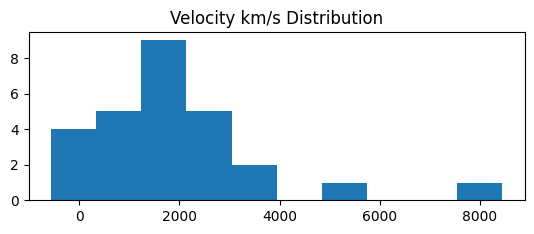

In [45]:
#plotting distributions using Fixed Diameter Method data
#histograms show the frequency of the x values in the y axis

plt.subplot(2, 1, 2)
plt.hist(cleaned_lab_data['Velocity(km/s)'])
plt.title('Velocity km/s Distribution')
plt.show()


This is a histogram of the recession velocity distribution from the cleaned lab data or the Fixed Diameter Method Data. It shows that most spiral galaxies in this data have a receding velocity of 0 to 3,000 km/s away from Earth, similar to the Fixed Magnitude Method Data, but at a smaller scale due to it being only 27 spiral galaxies. At this scale, it is hard to see curves. 

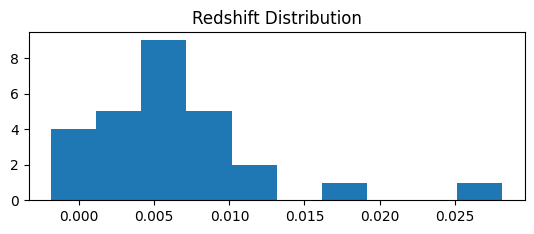

In [46]:
plt.subplot(2, 1, 2)
plt.hist(cleaned_lab_data['Redshift'])
plt.title('Redshift Distribution')
plt.show()


This is a histogram of the redshift distribution from the 27 spiral galaxies in the lab data. Most counts are from 0 to 0.013. This makes sense because the data is from the closest spiral galaxies or the late local universe not the baby universe. 

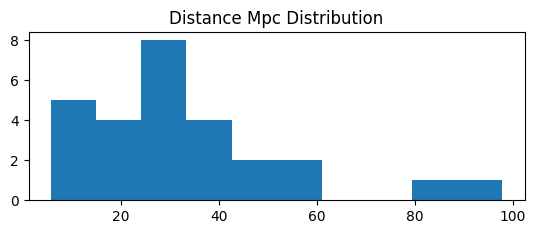

In [47]:
plt.subplot(2, 1, 2)
plt.hist(cleaned_lab_data['Distance(Mpc)'])
plt.title('Distance Mpc Distribution')
plt.show()

This is a histogram of the distance distribution for the lab data. Most of the 27 spiral galaxies are between 1 and 60 Megaparsecs or 60 million x 19.2 trillion miles. There also seems to be one that is 80 to 90 Megaparsecs. 

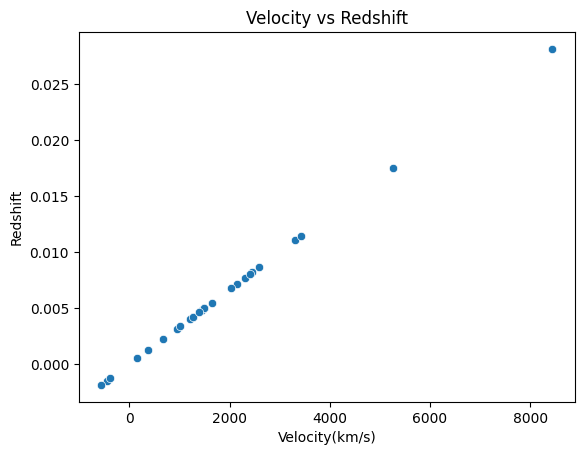

In [48]:
# Scatter plot of velocity vs redshift showing linear relationship more clearly

plt.figure()
sns.scatterplot(x='Velocity(km/s)', y='Redshift', data=cleaned_lab_data)
plt.title('Velocity vs Redshift')
plt.show()


This is a scatter plot of the 27 spiral galaxies from the lab data showing the direct relationship between redshift and velocity more clearly. The higher the velocity, the higher the redshift. 

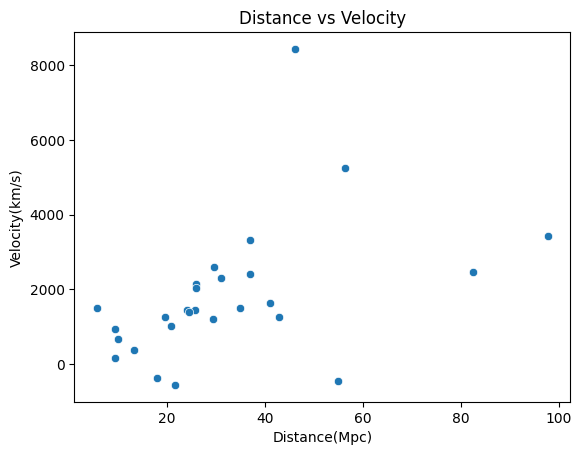

In [49]:
# Scatter plot of Distance vs Velocity showing a pre-model of Hubble's Law before we use linear regression

plt.figure()
sns.scatterplot(x = 'Distance(Mpc)', y = 'Velocity(km/s)', data=cleaned_lab_data)
plt.title('Distance vs Velocity')
plt.show()

This is a scatter plot of distance v velocity from the lab data. With only 27 spiral galaxies in our data, this may lead to a less accurate approximation of Hubble's constant after applying linear refression. 

#### **Fixed Magnitude Method Data Visuals**

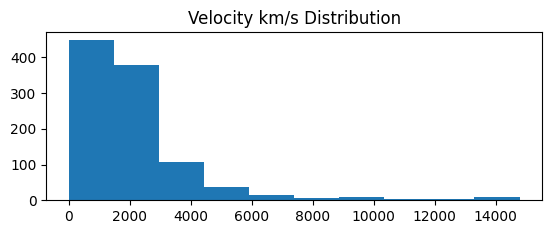

In [50]:
#plotting distributions using Fixed Magnitude Method data series
#histograms show the frequency of the x values in the y axis


plt.subplot(2, 1, 2)
plt.hist(cleaned_galaxy_data['Velocity(km/s)'])
plt.title('Velocity km/s Distribution')
plt.show()



This is a histogram for the recession velocity from Earth, from the cleaned NED galaxy data, or the Fixed Magnitude Method Data. Most spiral galaxies in this data have a recession velocity between 0 and 3000 km/s from Earth. With 1014 entries, at this scale, we start to see a curve that starts high and falls quickly. 

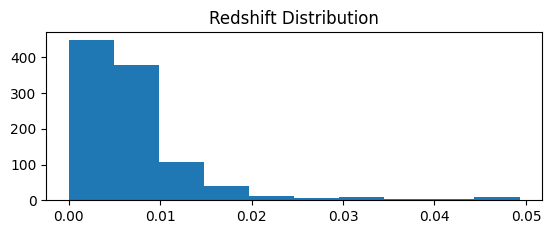

In [51]:

plt.subplot(2, 1, 2)
plt.hist(cleaned_galaxy_data['Redshift'])
plt.title('Redshift Distribution')
plt.show()



This is a histogram for galaxy redshift. The redshift distribution closely resembles the velocity distribution shown above. This points to a linear relationship between velocity and redshift. This also shows the constraints we set earlier on redshift. To avoid relativistic effects and errors in Hubble's constant, we set the constraint to z < 0.05. 

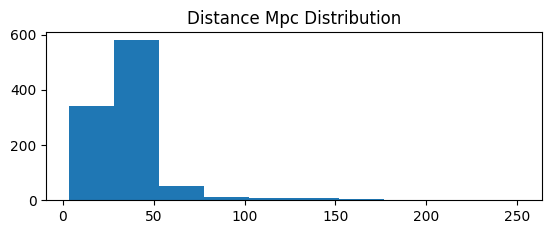

In [52]:

plt.subplot(2, 1, 2)
plt.hist(cleaned_galaxy_data['Distance(Mpc)'])
plt.title('Distance Mpc Distribution')
plt.show()



This histogram shows that most spiral galaxies from the data, 1014 entries, are 0 to 50 Megaparsecs (50,000,000 parsecs) away from Earth. For context, 1 parsec is 3.26 light-years or 19.2 trillion miles. This makes sense because the farthest galaxies are either too dim or outside the redshift constraint z < 0.05. Galaxies with redshifts above 0.05 are not shown. 

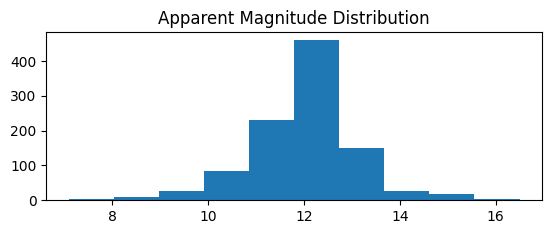

In [53]:

plt.subplot(2, 1, 2)
plt.hist(cleaned_galaxy_data['Magnitude'])
plt.title('Apparent Magnitude Distribution')
plt.show()

This histogram shows the distribution of galaxies' apparent magnitudes. It shows that most spiral galaxies in this data file, 1014, have an apparent magnitude between 11 and 13. Apparent magnitude goes from brightest to dimmest, lowest to highest values, respectively. For context, the apparent magnitude of the sun is -26.74, really, really bright. Most galaxies are dim between 11 and 13. Our closest spiral galaxy is M31, Andromeda, and it has an apparent magnitude of 3.4 to 3.44. 

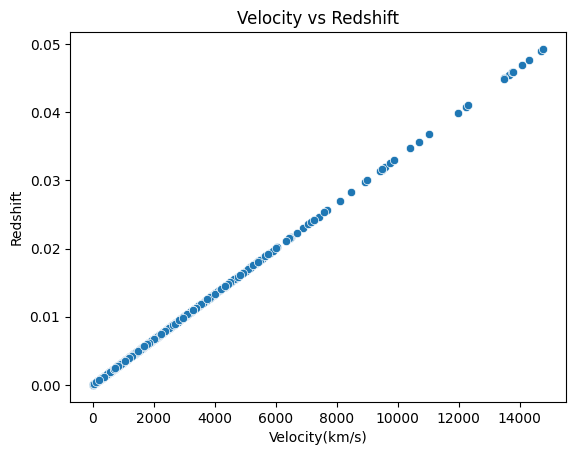

In [54]:
# Scatter plot of velocity vs redshift showing linear relationship more clearly

plt.figure()
sns.scatterplot(x='Velocity(km/s)', y='Redshift', data=cleaned_galaxy_data)
plt.title('Velocity vs Redshift')
plt.show()

This is a scatter plot of velocity v redshift from the galaxy data with 1014 entries. The higher the velocity, the higher the redshift. This makes sense due to the Doppler effect. Galaxies that recede faster are more redshifted, kind of like how the sound of a horn gets lower and lower as it speeds away from a stationary object. We say redshifted because the longer wavelengths are reddish on the light spectrum. 

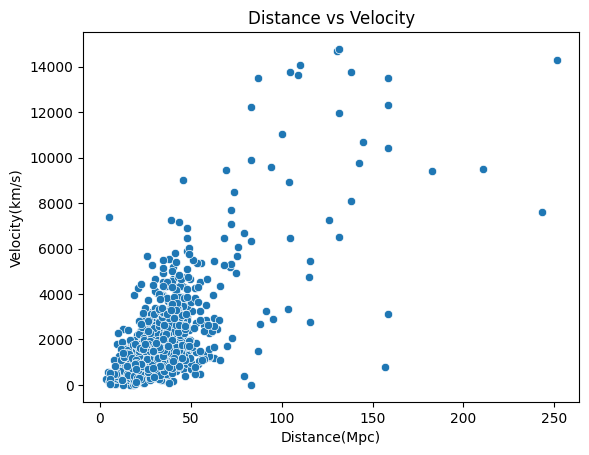

In [55]:
# Scatter plot of Distance vs Velocity showing a pre-model of Hubble's Law before we use linear regression

plt.figure()
sns.scatterplot(x = 'Distance(Mpc)', y = 'Velocity(km/s)', data=cleaned_galaxy_data)
plt.title('Distance vs Velocity')
plt.show()

This scatter plot shows distance v velocity from the fixed magnitude method data or the 1014 entries from the NED data. With this amount of spiral galaxies, once we use linear regression, it may give a better approximation of Hubble's constant (slope) than the 27 galaxies in the Fixed Diameter Method. 

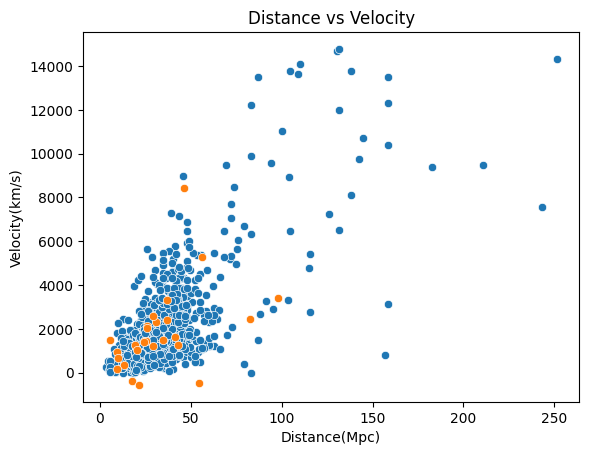

In [56]:
#scatter plot with both data series, blue and orange
plt.figure()
sns.scatterplot(x = 'Distance(Mpc)', y = 'Velocity(km/s)', data=cleaned_galaxy_data)
sns.scatterplot(x = 'Distance(Mpc)', y = 'Velocity(km/s)', data=cleaned_lab_data)
plt.title('Distance vs Velocity')
plt.show()

We can plot both data series in the same scatter plot to compare. We can see that the 27 spiral galaxies are some of the closest galaxies to Earth and don't go beyond 100 Megaparsecs from Earth. Having more data from the NED database gives us a better and bigger picture of our late universe and should lead to a better approximation of Hubble's constant once linear regression is applied. This is the most important visual before we apply machine learning. It gives us a mental model of the motion of the local universe, the galaxies closest to us, all the way to 250 Megaparsecs or 250 million x 19.2 trillion miles away. We can see that there is also a lot of space between our closest galaxies and the farthest ones, and the space between them seems to get bigger the farther the galaxy. 

### **Machine Learning Model**

#### **Linear Regression**
<br>

x = distance in Megaparsecs <br>
y = velocity in kilometers per second <br>

To find Hubble's constant, we need to make the x values the distance (Mpc) and the y values the velocity km/s). The slope will be the velocity over distance and should approximate 67 to 74 km/s/Mpc. 

The first scatter plot with a regression line shows us what the model would look like with only 27 spiral galaxies using a fixed diameter and angular size. The slope is 38.8875090868766, which is way off from 67 to 74 km/s/Mpc.

The second scatter plot with a regression line shows us what the model would look like with 1014 spiral galaxies using the fixed absolute magnitude method. The slope is 60.131705158765094, which is way closer to Hubble's constant than the initial model. We can see that the more data we acquire and analyze, the better our approximation for Hubble's constant is. 

Our models predicted a constant of 39 and 60 km/s/Mpc. Errors in the angular size measured manually and manual measurements of the light spectra could have contributed to some of the errors in the first model. The biggest factors of error would be the number of entries or data points we have, and the fixed diameter we used for spiral galaxies, 22 kiloparsec. We need lots of data for linear regression to work well, and galaxies come in different shapes and sizes. Constraining galaxy size to only 22 kpc would cause a significant error in the model. 

The second model also had some error, being almost 10 km/s/Mpc off. This could have been due to the fixed value we used for absolute magnitude -20.5. Like before, galaxies come in different shapes, sizes, and brightness, so using -20.5 for all of them would have caused some error.

For the age of the universe, we used Hubble's constant to estimate this value. First, we found the inverse of Hubble's constant and then converted it to seconds, and then divided the seconds in a year. The result is in years, so we divided by factors of 10 and got 25 billion years using the fixed diameter and 16 billion years using the fixed magnitude method. Again, the fixed magnitude method gives a better approximation since the universe is estimated to be around 13.8 billion years old. 

The two main methods scientists use to find Hubble's constant are the Cosmic Microwave Background and the local universe method. This project is similar to what a local universe measurement of Hubble's constant would be. The accepted value of our local universe is around 70-76 km/s/Mpc, and the accepted value of the early universe (CMB) is around 67 km/s/Mpc. This discrepancy is called Hubble's Tension.


In [57]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [58]:
#loaded the library for linear regression
from sklearn.linear_model import LinearRegression

#defined the x and y series
x = cleaned_lab_data[['Distance(Mpc)']]
y = cleaned_lab_data['Velocity(km/s)']

#called on linear regression and fit()
model = LinearRegression(fit_intercept=True)
model.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


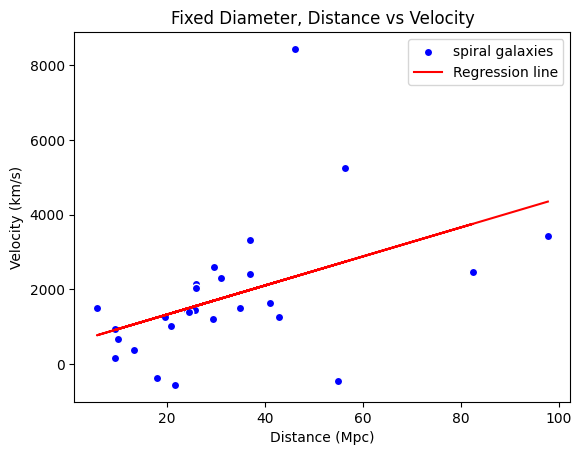

In [59]:
#called predict, so the model predicts the y values 
yfit =  model.predict(x)

#scatter plot is called with defined colors and labels
plt.scatter( x, y, color='blue', edgecolors= 'white', label='spiral galaxies')

#regression line is plotted using yfit with defined colors and label
plt.plot( x, yfit, color='red', label='Regression line')

#x axis is labeled
plt.xlabel('Distance (Mpc)')

#y axis is labeled
plt.ylabel('Velocity (km/s)')

#titled plot
plt.title('Fixed Diameter, Distance vs Velocity')

#legend for plot is shown
plt.legend()


In [60]:
H0_1 = model.coef_[0]
print("slope:" , H0_1, "km/s/Mpc")
print("y-intercept:" , model.intercept_, "km/s")
print("predicted velocities:", yfit)

slope: 38.8875090868766 km/s/Mpc
y-intercept: 548.6260923499101 km/s
predicted velocities: [1558.69126328 1559.88519381 1758.70416845 1488.76367483 1061.83856988
  915.9619446  1698.52555447 1546.90520553 1902.30520604 2345.94794071
 1306.39863449 2682.10539377 3752.84032441  911.75223832  936.79542082
 1693.90748428 1245.30785138  769.69203548 2147.73861566 1354.96464066
 2742.28045109 1389.85047768 1986.48357135 2219.57374843 1500.26702662
 1981.6666281  4350.96031426]


In [61]:


#defined the x and y series
x = cleaned_galaxy_data[['Distance(Mpc)']]
y = cleaned_galaxy_data['Velocity(km/s)']

#called on linear regression and fit()
model = LinearRegression(fit_intercept=True)
model.fit(x, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


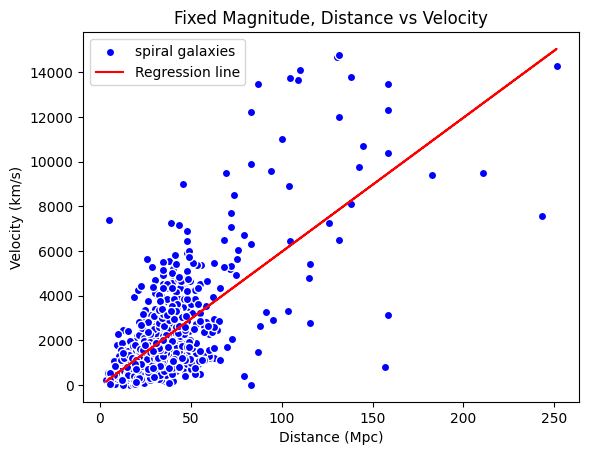

In [62]:
#called predict, so the model predicts the y values 
yfit =  model.predict(x)

#scatter plot is called with defined colors and labels
plt.scatter( x, y, color='blue', edgecolors= 'white', label='spiral galaxies')

#regression line is plotted using yfit with defined colors and label
plt.plot( x, yfit, color='red', label='Regression line')

#x axis is labeled
plt.xlabel('Distance (Mpc)')

#y axis is labeled
plt.ylabel('Velocity (km/s)')

#titled plot
plt.title('Fixed Magnitude, Distance vs Velocity')

#legend for plot is shown
plt.legend()


In [63]:
H0_2 = model.coef_[0]
print("slope:" , H0_2, "km/s/Mpc")
print("y-intercept:" , model.intercept_, "km/s")
print("predicted velocities:", yfit)

slope: 60.131705158765094 km/s/Mpc
y-intercept: -55.40881787858052 km/s
predicted velocities: [1497.34826639 2405.54531452 4300.74813789 ... 2029.57898803  694.66415911
 2294.7841331 ]


In [64]:
#the predicted Age of the Universe based on Hubble's constant

# We used the Galaxy Lab from the University of Washington for this equation

#to find age, find the inverse of Hubble's constant, 1/H0
#then convert to seconds and cancel distance units with, x 3.09 x 10^19 km/Mpc
#then we converted the seconds to years by dividing by seconds in a year, 3.16 x 10^7 seconds/year

Age_1 = ((1/H0_1)*(3.09*(10**19)))/(3.16 * (10**7))
Age_1 = int(Age_1/(10**9))

Age_2 = ((1/H0_2)*(3.09*(10**19)))/(3.16 * (10**7))
Age_2 = int(Age_2/(10**9))

print("Age of Universe with Fixed Diameter Method:", Age_1, "billion years")
print("Age of Universe with Fixed Magnitude Method:", Age_2, "billion years")

Age of Universe with Fixed Diameter Method: 25 billion years
Age of Universe with Fixed Magnitude Method: 16 billion years


### **Validation**

**Percentage Error**
<br>
The accepted value for Hubble's constant is 68 -  74 km/s/Mpc, a range that comes from the early universe and ends in the late universe. We can calculate a percentage erorr using the values from our data analysis and the accepted value. Percentage error = 

$$\frac{|Experiment - Accepted|}{Accepted} \times 100 $$

Fixed Diameter Method:
$$\frac{|38.8875090868766 - (68 -> 74)|}{68 -> 74} \times 100 = 42 -> 47 $$

Fixed Magnitude Method:
$$\frac{|60.131705158765094 - (68 -> 74)|}{(68 -> 74)} \times 100 = 12 -> 19  $$

The percentage error for fixed diameter data is 42 to 47 percent and for the fixed absolute magnitude data it is 12 to 19 percent. The fixed magnitude method is a better predictor of Hubble's constant. The percentage error for the age of the universe using the fixed magnitude data above is (16 billion years - 13.8 billion years) /13.8 billion years = 16 percent when using the accepted value of 13.8 billion years. 


  

**Cross Validation**
<br>

cross_val_score(mode, x, y, cv = 5):<br>
The data is split into 5 equal subsets. One subset is used for validation while 4 are used for training. Each subset takes a turn being used for validation while the other 4 are used for training. 


R^2 Legend: <br>
R^2 = 1, every galaxy sits on the line. There is no noise or outliers. <br>
R^2 = 0, every galaxy is random showing no linear relationship <br>
R^2 = 0.5, 50 percent of the variation in velocites is due to the distance from Earth<br>
<br>

**Fixed Diameter Method Data:**
<br>

We used the library sklearn and the function cross_val_score() with the parameters model, x, y, and cv = 5 for 5 folds. Each subset is about 7 to 6 galaxies. The R^2 scores for each fold are 0.53611383, -0.03203906, -0.50935448,  0.35165082, -0.25653702, and the average of all of them is 0.02. This means 2 percent of the variation in velocities is due to the distance. There R^2 scores for this model are so bad, there's no justification to keep using this model. We can end the data analysis for this model here. 

<br>
  
**Fixed Magnitude Method Data:**
<br>

We set the same parameter with cv = 5 for 5 folds in cross_val_score and got the following R^2 values: 0.52009616, 0.28329054, 0.11595527, 0.53185736, 0.4952887. Each subset is about 202 to 203 galaxiesThe average of all of these is 0.39. This means 39 percent of the variation in velocities is due to the distance. The R^2 scores are better than the previous model and there are no negative scores. An average of 39 means that there is a relationship. 

    

In [65]:
##from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_score


#define data vairables
x = cleaned_lab_data[['Distance(Mpc)']]
y = cleaned_lab_data['Velocity(km/s)']


#initialize
model = LinearRegression()

#find scores using 5 fold cross validation
scores = cross_val_score(model, x, y, cv = 5)

#mean of scores above
mean = scores.mean()

#results
print("R^2 scores for each subset:", scores)
print("Average model performance:", mean)


R^2 scores for each subset: [ 0.53611383 -0.03203906 -0.50935448  0.35165082 -0.25653702]
Average model performance: 0.017966817799850897


There are some R^2 values that are negative, 3 out of 5 of them. This suggests poor correlation and an R^2 value closer to 0 than 1. A value closer to 0 suggests random data and noise. This is due to the fact that we manually measured the apparent angular size of the spiral galaxies using images and then we used a fixed diameter of 22 kpc for all 27 spiral galaxies. Galaxies vary in size or diameter significantly. The last thing is that our sample size is way too small at 27 that it increases the influence of error from any outlier in our model. A larger sample size would make any single outlier less and less significant. Overall, the fixed diameter method is highly unreliable and we can stop using it. 

In [66]:

#define data vairables
x = cleaned_galaxy_data[['Distance(Mpc)']]
y = cleaned_galaxy_data['Velocity(km/s)']


#initialize
model = LinearRegression()


#find scores using 5 fold cross validation
scores = cross_val_score(model, x, y, cv = 5)

#mean of scores above
mean = scores.mean()

#results
print("R^2 scores for each subset:", scores)
print("Average model performance:", mean)


R^2 scores for each subset: [0.52009616 0.28329054 0.11595527 0.53185736 0.4952887 ]
Average model performance: 0.3892976058970169


All of the scores are positive numbers which confirms a positive linear relationship found between distance and velocity and the confirmation of Hubble's Law. The missing percentage is due to outliers and the fact that we used a fixed absolute magnitude of -20.5 knowing that each galaxy varies in brightness. We did this for practical reasons and for easy data modeling. The R^2 value is predicted to be higher or closer to 1 if every galaxy uses the correct absolute magnitude to calculate distance from Earth. 

### **Feature Engineering**

**Using Polynomial Features**

Hubble's Law is famous for its linear relationship and it's not scientific to assume that it needs polynomial features or curves to fit the data. However, since this is a data analysis project where the data contains noise and peculiar velocities, we used a polynomial feature to see how it might change our model. We will be focused on the fixed magnitude model only. 

**Fixed Magnitude Method Data:**

This is the data we want to use for more serious estimation after being cross validated. When we applied a polynomial, the first coefficient came out to 71 km/s/Mpc which is within the official accepted range of Hubble's constant. This is a significant improvement from 60 km/s/Mpc. However, we cannot use a curve to describe Hubble's Law since it's supposed to be a line, the linear relationship between distance and velocity of the galaxies. The slope shows us the rate of expansion and using a curve would be like cheating. Since the first coefficient was 71 km/s/Mpc we make an inference that if we discount outliers or galaxies with peculiar velocities then we can get a better approximation using linear regression. 

**Fixing the Data**

After taking out outliers from the dataset and redoing linear regression, we came up with a value lower than before, around 57 km/s/Mpc. This was unexpected because we were expecting the slope to approximate 67 to 74 km/s/Mpc but instead it just got father from that. Then, we tried putting a limit on the distance in our data and we calculated the slope for each model according to the distance limit. We found that there were a few distance limits where we could limit the data to get the best approximations to Hubble's constant. These were at 15 Mpc, 16 Mpc, and 17 Mpc. Then the slope fell down below 60 beyond those distances. Instead of fixing the data, we found that taking out the outliers in velocities beyond 3 standard deviations didn't help. We found that taking out the farthest galaxies didn't help either until 15 to 17 Mpc. The work can be found below. 


slope: 60.131705158765094 km/s/Mpc


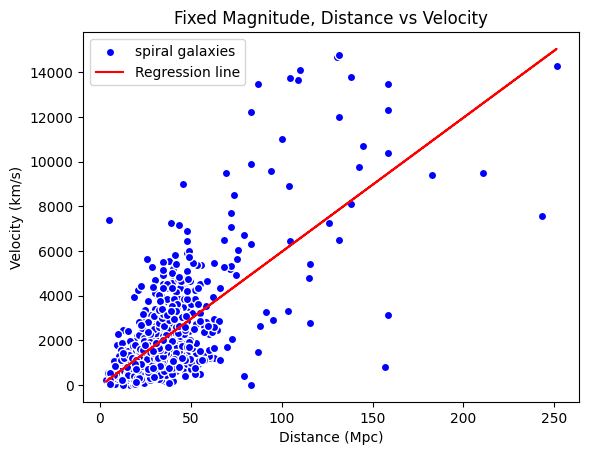

In [67]:
#Fixed Magnitude Method Data Model

#defined the x and y series
x = cleaned_galaxy_data[['Distance(Mpc)']]
y = cleaned_galaxy_data['Velocity(km/s)']

#called on linear regression and fit()
model = LinearRegression(fit_intercept=True)
model.fit(x, y)

#called predict, so the model predicts the y values 
yfit =  model.predict(x)

#scatter plot is called with defined colors and labels
plt.scatter( x, y, color='blue', edgecolors= 'white', label='spiral galaxies')

#regression line is plotted using yfit with defined colors and label
plt.plot( x, yfit, color='red', label='Regression line')

#x axis is labeled
plt.xlabel('Distance (Mpc)')

#y axis is labeled
plt.ylabel('Velocity (km/s)')

#title
plt.title('Fixed Magnitude, Distance vs Velocity')

#legend for plot
plt.legend()


#Hubble's constant, model number 2, fixed magnitude, coefficient 0 
H0_2 = model.coef_[0]
print("slope:" , H0_2, "km/s/Mpc")


In [68]:
#call library for polynomial features
from sklearn.preprocessing import PolynomialFeatures

#defining polynomial with 2 degrees 
poly = PolynomialFeatures(degree=2, include_bias=False)
#defining x2, 2d array, x and x^2
x2 = poly.fit_transform(x)

#print features
print("Original Features:")
print(x)
print("Polynomial Features:")
print(x2)

Original Features:
      Distance(Mpc)
0         25.822602
1         40.926066
3         72.443596
4         37.670380
6         25.703958
...             ...
1115      47.206304
1116      40.926066
1117      34.673685
1118      12.473835
1119      39.084090

[1014 rows x 1 columns]
Polynomial Features:
[[  25.82260191  666.80676921]
 [  40.92606597 1674.94287603]
 [  72.44359601 5248.0746025 ]
 ...
 [  34.67368505 1202.26443462]
 [  12.47383514  155.59656316]
 [  39.08408958 1527.56605824]]


In [69]:
#train model with poly features
model = LinearRegression()
model.fit(x2, y)

#first coefficient is Hubble's constant, model number 2, fixed magnitude 
H0_2 = model.coef_[0]

#second coefficient, negative means downward curve
curve = model.coef_[1]

#print features
print("slope:" , H0_2, "km/s/Mpc")
print("curve:" , curve, "km/s/Mpc")


slope: 71.04403762097651 km/s/Mpc
curve: -0.06690317774101831 km/s/Mpc


slope: 71.04403762097651 km/s/Mpc
curve: -0.06690317774101831 km/s/Mpc


C:\Users\maybe\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


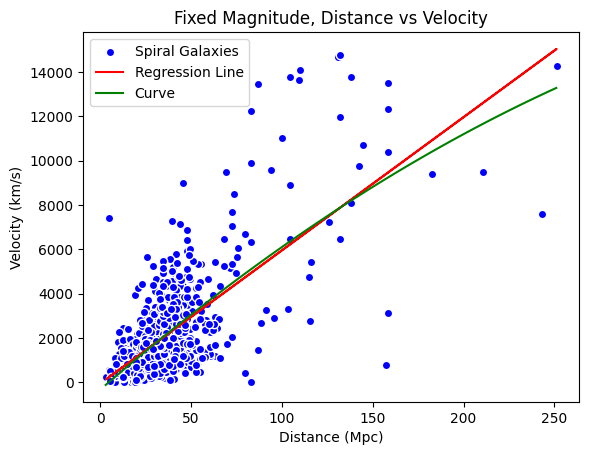

In [70]:
#Plotting polynomial features

#to create a smooth curve we need to turn floating numbers in distance column 
#to integers and create 100 equal values in the x axis to plot 
x_int = x.astype(int)
x_plot = np.linspace(x_int.min(), x_int.max(), 100)

#we turn it into a polynomial with x and x^2 and predict y values
x_plot_poly = poly.transform(x_plot)
y_plot = model.predict(x_plot_poly)


#plot data scatter plot
plt.scatter(x,y, color='blue', edgecolors= 'white', label='Spiral Galaxies')

#straight line, regression line, plotted using yfit, blue
plt.plot( x, yfit, color='red', label='Regression Line')

#curve, fitted to data, 2 degrees, green 
plt.plot(x_plot, y_plot, color='green', label='Curve')


#x axis is labeled
plt.xlabel('Distance (Mpc)')

#y axis is labeled
plt.ylabel('Velocity (km/s)')

#title
plt.title('Fixed Magnitude, Distance vs Velocity')

#legend for plot
plt.legend()


#coefficient 1 and 2 in polynomial
print("slope:" , H0_2, "km/s/Mpc")
print("curve:" , curve, "km/s/Mpc")

Residual for Velocity:
0       -446.348266
1        -95.545315
3       3386.251862
4      -1655.775359
6      -1023.213996
           ...     
1115     314.813257
1116     552.454685
1117    2305.421012
1118    -467.664159
1119     995.215867
Name: Velocity(km/s), Length: 1014, dtype: float64


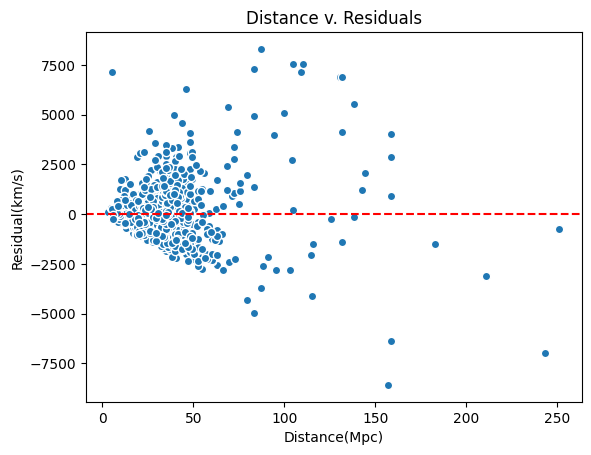

In [71]:
#finding residuals manually, actual value minus prediction, y - yfit
model = LinearRegression()
model.fit(x, y)

#create residual 
yfit = model.predict(x)
residual = y - yfit

#plot for residuals
plt.scatter(x, residual, edgecolors= 'white', label='Spiral Galaxies')
plt.axhline(y=0, color='red', linestyle='--')

#x axis is labeled
plt.xlabel('Distance(Mpc)')

#y axis is labeled
plt.ylabel('Residual(km/s)')

#titled plot
plt.title('Distance v. Residuals')

#print out residual values for each spiral galaxy
print("Residual for Velocity:")
print(residual)

This residual plot shows us how far away each data point or galaxy is from the line or the predicted value. When a predicted value is equal to the actual value then the dot will fall on the dotted line. The more difference there is between values the more residual there is. 

In [72]:
#Standard Deviation for the Velocity(km/s) Series in Fixed Magnitude Data 
#is Standard Deviation: 1999.1374929370782 or 2000 km/s
#Anything more than 3 standard deviations from the predicted value 
#is an outlier and can be taken out, residual > |6000 km/s|

#we create a standard deviation condition, the absolute value of the residual has to be 
#less than 6000, or 3 Standard Deviations away from the predicted value to be included in data
sd_condition = abs(residual) < 6000

galaxy_data_filtered = cleaned_galaxy_data[sd_condition]

galaxy_data_filtered = galaxy_data_filtered.dropna(subset=['Distance(Mpc)'])

print('Galaxies with Velocity Residuals less than 3 Standard Deviations')
print( galaxy_data_filtered['Velocity(km/s)'])


Galaxies with Velocity Residuals less than 3 Standard Deviations
0       1051
1       2310
3       7687
4        554
6        467
        ... 
1115    3098
1116    2958
1117    4335
1118     227
1119    3290
Name: Velocity(km/s), Length: 1002, dtype: int64


slope: 57.91645807528048 km/s/Mpc
y-intercept: 0.0 km/s
predicted velocities: [1495.5536407  2370.29278411 4195.67649099 ... 2008.17702624  722.44035006
 2263.61203553]


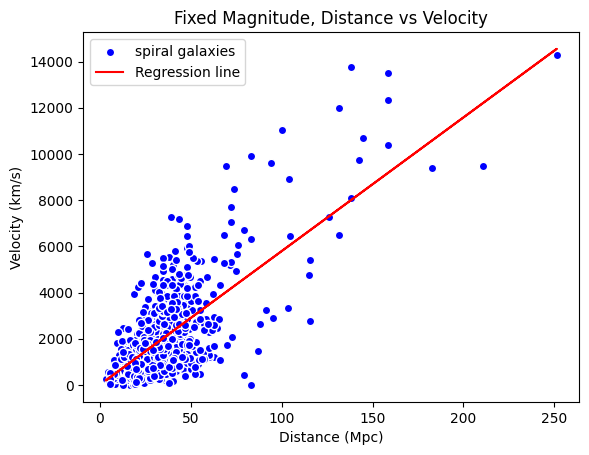

In [73]:
# New model without outliers and y intercept of 0. 

#redefine x and y with new filtered data
x = galaxy_data_filtered[['Distance(Mpc)']]
y = galaxy_data_filtered['Velocity(km/s)']

#redefine model
model = LinearRegression(fit_intercept=False)
model.fit(x, y)
yfit =  model.predict(x)

#scatter plot is called with defined colors and labels
plt.scatter( x, y, color='blue', edgecolors= 'white', label='spiral galaxies')

#regression line is plotted using yfit with defined colors and label
plt.plot( x, yfit, color='red', label='Regression line')

#x axis is labeled
plt.xlabel('Distance (Mpc)')

#y axis is labeled
plt.ylabel('Velocity (km/s)')

#titled plot
plt.title('Fixed Magnitude, Distance vs Velocity')

#legend for plot is shown
plt.legend()

#print slope and intercept and velocities
H0 = model.coef_[0]
print("slope:" , H0, "km/s/Mpc")
print("y-intercept:" , model.intercept_, "km/s")
print("predicted velocities:", yfit)

slope: 70.66932880149916 km/s/Mpc
y-intercept: 0.0 km/s
7        7.379042
14      11.803206
15       3.296097
20       7.762471
23       6.606934
          ...    
985      8.472274
1017     5.571857
1018    12.589254
1065    14.791084
1118    12.473835
Name: Distance(Mpc), Length: 82, dtype: float64


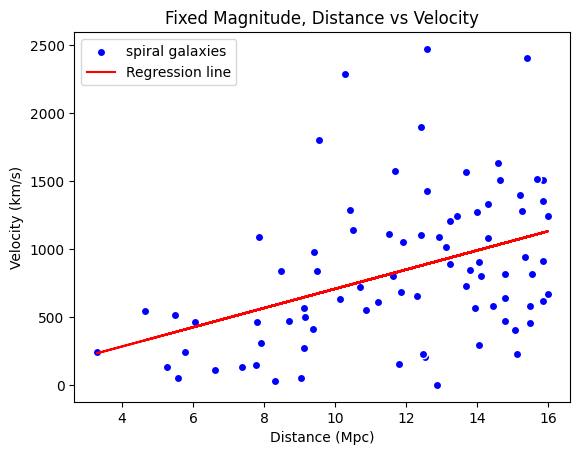

In [74]:
#define distance
x = galaxy_data_filtered['Distance(Mpc)']

#set condition, we find that a distance limit of 16 Mpc
#gives a better approximation for Hubble's constant, 71 km/s/Mpc 
distance_condition = x < 16

#filter with condition
galaxy_distance_filtered = galaxy_data_filtered[distance_condition]

#redefine x and y with new filtered data
x = galaxy_distance_filtered[['Distance(Mpc)']]
y = galaxy_distance_filtered['Velocity(km/s)']

#redefine model
model = LinearRegression(fit_intercept=False)
model.fit(x, y)
yfit =  model.predict(x)

#scatter plot is called with defined colors and labels
plt.scatter( x, y, color='blue', edgecolors= 'white', label='spiral galaxies')

#regression line is plotted using yfit with defined colors and label
plt.plot( x, yfit, color='red', label='Regression line')

#x axis is labeled
plt.xlabel('Distance (Mpc)')

#y axis is labeled
plt.ylabel('Velocity (km/s)')

#titled plot
plt.title('Fixed Magnitude, Distance vs Velocity')

#legend for plot is shown
plt.legend()

#print slope and intercept and velocities
H0 = model.coef_[0]
print("slope:" , H0, "km/s/Mpc")
print("y-intercept:" , model.intercept_, "km/s")
print( galaxy_distance_filtered['Distance(Mpc)'])


In [75]:
#new plot to find at what distances slope is equal to 70km/s/Mpc or above

y_slopes = []
x_distance = []


for i in range(251):
    x = galaxy_data_filtered['Distance(Mpc)']
    
    distance_condition = x < i

    #filter with condition
    galaxy_distance_filtered = galaxy_data_filtered[distance_condition]

    
    #check for enough data for slope
    #redefine x and y with new filtered data
    if len(galaxy_distance_filtered) > 1:
        x = galaxy_distance_filtered[['Distance(Mpc)']]
        y = galaxy_distance_filtered['Velocity(km/s)']

        #redefine model
        model = LinearRegression(fit_intercept=False)
        model.fit(x, y)
        yfit =  model.predict(x)

        y_slopes.append(int(model.coef_[0]))
        x_distance.append(i)

print(y_slopes)
print(x_distance)


[102, 55, 51, 53, 53, 63, 76, 75, 76, 76, 73, 70, 68, 66, 61, 62, 61, 60, 61, 60, 60, 61, 61, 59, 59, 58, 58, 57, 57, 56, 58, 57, 56, 56, 56, 56, 56, 56, 57, 57, 57, 57, 56, 57, 57, 57, 57, 57, 56, 56, 56, 56, 56, 56, 56, 56, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57]
[5, 6, 7, 8, 9

Distance Limit:  15 Mpc, Slope: 73 km/s/Mpc
Distance Limit:  16 Mpc, Slope: 70 km/s/Mpc
Distance Limit:  17 Mpc, Slope: 68 km/s/Mpc


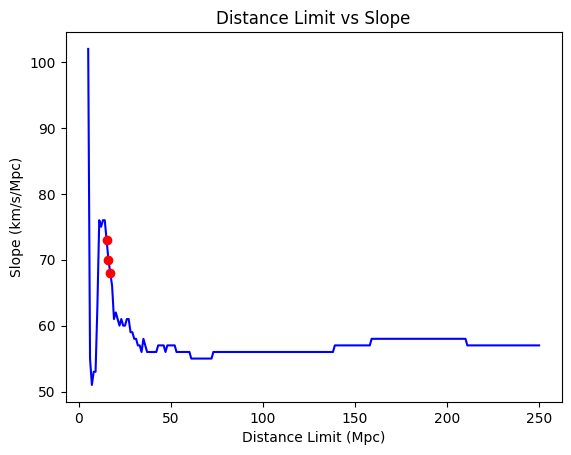

In [76]:

# new x and y for plot for slopes
x = x_distance
y = y_slopes

#simple plot
plt.plot( x, y, color='blue', label='slope')

#x axis is labeled
plt.xlabel('Distance Limit (Mpc)')

#y axis is labeled
plt.ylabel('Slope (km/s/Mpc)')

#titled plot
plt.title('Distance Limit vs Slope')

#for loop prints out the distance limit and the slope calculated at that distance limit
#it also plots in red dots where the best approximation of Hubble's constant is at
#the closest approximation of Hubble's constant is at the distance limit from 15 to 17. 
for i in range(len(y)):
    if 67 <= y[i] <= 74 :
        print("Distance Limit: ", x[i], "Mpc,", "Slope:" ,y[i], "km/s/Mpc")
        plt.plot( x[i], y[i],'ro')



In this plot we can see exactly where the best approximation of Hubble's constant is. It shows 3 dots at different distance limits. The 3 best are at distance limits, 15, 16, and 17. They gives us 73, 70, and 68 km/s/Mpc for Hubble's constant within the accepted parameters. Looking at the rest of the graph, we can also see where most of the line sits, between 55 and 60 km/s/Mpc. There seems to be something affecting the slope after 25 Mpc since it falls down quickly from 75 km/s/Mpc. 

### **Evaluation**

**Conclusion and Evaluation**
<br>
We tested both models for finding Hubble's constant but we confirmed that significant error was caused by using a fixed value for galaxy diameter and absolute magnitude. Galaxies come in many different sizes and brightnesses. Additionally, when measuring magnitudes we have to acknowledge that there is systemic bias in measuring the magnitudes of galaxies because the dimmest, farthest, and more redshifted galaxies are less likely to be found or detected. 

Many experiments done in college with easy to use small sample sizes to do manually, like the fixed diameter lab from the University of Washington showed us huge potential for error. It is much better to use large datasets and python than to handle data manually. Even if the data is messy like it was in the beginning, python gives us so many libraries and functions to preprocess. Using python and machine learning models like linear regression on astronomy data proves to be successful in large datasets. 

The fixed magnitude method proved to be the superior model. Even though we used a fixed absolute value for all 1014 spiral galaxies, there were enough entries that the noise was less significant. There was still significant error which we thought was due to noise when we added a polynomial feature where it identified non-linearities caused by systemic bias. After this, we tried taking out the velocity outliers beyond 6000 km/s from the line but this proved to be unhelpful and just made the slope decrease farther from Hubble's constant. Then, we tried taking out the farthest galaxies and recalculating the slope for every distance range from Earth. We found that the slopes with the best estimates were at the distance limit of 15, 16, and 17 Mpc. After this, the slope falls below 60 km/s/Mpc. 

This project also highlights the current tension in the science community with Hubble's constant. The two main methods used are with the cosmic microwave background(early universe) and the distance ladder method(the universe closest to us). The early universe gives us a value around 67-70 km/s/Mpc and the late universe gives us 70-74 km/s/Mpc. Scientists suggest that there might be external forces affecting Hubble's constant, like dark energy. If the universe was expanding slower during early universe, there could be a force like dark energy affecting late expansion.

### **References**
<br>

CouRseRa | Online courses & credentials from top educators. Join for free | CourseRA. (n.d.-g). Coursera. 
>https://www.coursera.org/learn/uol-cm3005-data-science/home/module/6

CouRseRa | Online courses & credentials from top educators. Join for free | CourseRA. (n.d.-f). Coursera. 
>https://www.coursera.org/learn/uol-cm3005-data-science/home/module/5

CouRseRa | Online courses & credentials from top educators. Join for free | CourseRA. (n.d.-e). Coursera. 
>https://www.coursera.org/learn/uol-cm3005-data-science/home/module/4

CouRseRa | Online courses & credentials from top educators. Join for free | CourseRA. (n.d.-d). Coursera. 
>https://www.coursera.org/learn/uol-cm3005-data-science/home/module/3

Wikipedia contributors. (2026, January 28). Cosmic distance ladder. Wikipedia.
>https://en.wikipedia.org/wiki/Cosmic_distance_ladder

Wikipedia contributors. (2025, September 2). Distance modulus. Wikipedia.
>https://en.wikipedia.org/wiki/Distance_modulus

GeeksforGeeks. (2026, February 20). How to calculate skewness and kurtosis in Python? GeeksforGeeks. 
>https://www.geeksforgeeks.org/data-science/how-to-calculate-skewness-and-kurtosis-in-python/

Linear regression in Python - Sustainability Methods. (n.d.).
>https://sustainabilitymethods.org/index.php/Linear_Regression_in_Python#:~:text=Linear%20regression%20implementation%20in%20Python%20First%20of,with%20the%20linear%20regression%20line%2C%20using%20matplotlib.

PolynomialFeatures. (n.d.). Scikit-learn. 
>https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html

CouRseRa | Online courses & credentials from top educators. Join for free | CourseRA. (n.d.-c). Coursera. 
>https://www.coursera.org/learn/uol-cm3005-data-science/home/module/7

Bobbitt, Z. (2020, September 7). How to plot a smooth curve in Matplotlib. Statology.
>https://www.statology.org/matplotlib-smooth-curve/#:~:text=Often%20you%20may%20want%20to,BSpline()

GeeksforGeeks. (2025, July 23). How to create a residual plot in Python. GeeksforGeeks.
>https://www.geeksforgeeks.org/python/how-to-create-a-residual-plot-in-python/

W3Schools.com. (n.d.). 
>https://www.w3schools.com/python/python_for_loops.asp

CouRseRa | Online courses & credentials from top educators. Join for free | CourseRA. (n.d.-b). Coursera. 
>https://www.coursera.org/learn/uol-cm3005-data-science/home/module/10

CouRseRa | Online courses & credentials from top educators. Join for free | CourseRA. (n.d.). Coursera. 
>https://www.coursera.org/learn/uol-cm3005-data-science/home/module/9

scikit-learn developers. (2019). sklearn.linear_model.LinearRegression — scikit-learn 0.22 documentation. Scikit-Learn.org. 
>https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

Unveiling Measures of Centrality: A Descriptive Statistics Journey with Python. (n.d.). CodeSignal Learn. 
>https://codesignal.com/learn/courses/descriptive-and-inferential-statistics-with-python/lessons/unveiling-measures-of-centrality-a-descriptive-statistics-journey-with-python

Python - Measuring central tendency. (n.d.).
>https://www.tutorialspoint.com/python_data_science/python_measuring_central_tendency.htm

Wikipedia Contributors. (2022, January 29). Tully–Fisher relation. Wikipedia; Wikimedia Foundation.
>https://en.wikipedia.org/wiki/Tully%E2%80%93Fisher_relation

‌Distance from absolute and apparent magnitude. (2023). VCalc. 
>https://www.vcalc.com/wiki/sspickle/Distance-from-absolute-and-apparent-magnitude

Vogel, T., & NASA. (2025, August 4). Hubble Constant and Tension. NASA Science. 
>https://science.nasa.gov/mission/hubble/science/science-behind-the-discoveries/hubble-constant-and-tension/

Grokipedia. (1970, January 21). Galaxy rotation curve. Grokipedia. 
>https://grokipedia.com/page/Galaxy_rotation_curve

AstroPages | Hubble’s Law - Activity Lab | Western Washington University. (2026). Wwu.edu.
>https://astro101.wwu.edu/a101_hubble_lab.html

‌Solve For a Variable Calculator - Symbolab. (2017). Symbolab.com. 
>https://www.symbolab.com/solver/solve-for-equation-calculator‌

josue.e.morejon. (2026). Astronomy and Astrophysics Formula Sheet. Scribd.
>https://www.scribd.com/document/870215640/Astronomy-and-Astrophysics-Formula-Sheet‌

The Hubble Law: Measurements of Velocities and Distances. (n.d.). Depts.washington.edu.
>https://depts.washington.edu/astroed/HubbleLaw/measurements.html‌

Far, Far Away: Just How Distant Is That Galaxy? (n.d.). National Radio Astronomy Observatory.
>https://public.nrao.edu/news/far-far-away-just-how-distant-is-that-galaxy/

Astronomy Simulations and Animations. (n.d.). Astro.unl.edu. 
>https://astro.unl.edu/animationsLinks.html

By Parameters | NASA/IPAC Extragalactic Database. (2018). Caltech.edu. 
>https://ned.ipac.caltech.edu/byparams

How Far Away is That Galaxy? Vast Catalog Has Answers. (2017, January 5). NASA Jet Propulsion Laboratory (JPL).
>https://www.jpl.nasa.gov/news/how-far-away-is-that-galaxy-vast-catalog-has-answers/‌


In [77]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
